In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

(X_train, y_train), (X_test, y_test) = cifar100.load_data(label_mode='fine')

print("X_train shape: ", X_train.shape)
print("y_train shape: ", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (50000, 32, 32, 3)
y_train shape:  (50000, 1)
X_test shape:  (10000, 32, 32, 3)
y_test shape:  (10000, 1)


In [ ]:
#Exam Question: CIFAR-10 has 10 classes, so each class has many examples with obvious differences. CIFAR-100 has 100 classes,
#with fewer images per class, and the classes are similar, making it a more challenging dataset

In [ ]:
#Normalize images to the range[0, 1].

X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

#Convert labels to one-hot encoding
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

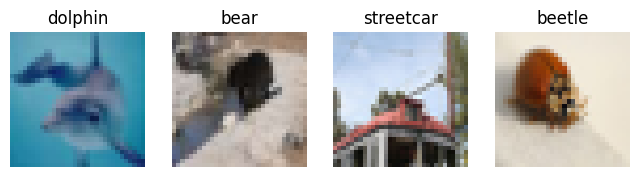

In [ ]:
label_names = [
    "apple",
    "aquarium_fish",
    "baby",
    "bear",
    "beaver",
    "bed",
    "bee",
    "beetle",
    "bicycle",
    "bottle",
    "bowl",
    "boy",
    "bridge",
    "bus",
    "butterfly",
    "camel",
    "can",
    "castle",
    "caterpillar",
    "cattle",
    "chair",
    "chimpanzee",
    "clock",
    "cloud",
    "cockroach",
    "couch",
    "crab",
    "crocodile",
    "cup",
    "dinosaur",
    "dolphin",
    "elephant",
    "flatfish",
    "forest",
    "fox",
    "girl",
    "hamster",
    "house",
    "kangaroo",
    "keyboard",
    "lamp",
    "lawn_mower",
    "leopard",
    "lion",
    "lizard",
    "lobster",
    "man",
    "maple_tree",
    "motorcycle",
    "mountain",
    "mouse",
    "mushroom",
    "oak_tree",
    "orange",
    "orchid",
    "otter",
    "palm_tree",
    "pear",
    "pickup_truck",
    "pine_tree",
    "plain",
    "plate",
    "poppy",
    "porcupine",
    "possum",
    "rabbit",
    "raccoon",
    "ray",
    "road",
    "rocket",
    "rose",
    "sea",
    "seal",
    "shark",
    "shrew",
    "skunk",
    "skyscraper",
    "snail",
    "snake",
    "spider",
    "squirrel",
    "streetcar",
    "sunflower",
    "sweet_pepper",
    "table",
    "tank",
    "telephone",
    "television",
    "tiger",
    "tractor",
    "train",
    "trout",
    "tulip",
    "turtle",
    "wardrobe",
    "whale",
    "willow_tree",
    "wolf",
    "woman",
    "worm"
]

indices = np.random.choice(len(X_train), 4, replace =False)

plt.figure(figsize=(8, 3))
for i, idx in enumerate (indices):
  plt.subplot(1, 4, i+1)
  plt.imshow(X_train[idx])
  plt.title(label_names[y_train[idx][0]])
  plt.axis('off')
plt.show()

In [ ]:
#Exam Question: Images are only 32x32 pixels which limits the amount of visula data the model can see, with the reduces images for the 100 classes(limited data),
#a CNN may find it hard learning the classes. Important features may also be blurry or lost.

In [ ]:
def cnn_model(input_shape=(32, 32, 3)):

  model = Sequential()

  #Conv block 1: 32 filters, Maxpool
  model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=input_shape))
  model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  #Conv block 2: 64 filters, Maxpool
  model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
  model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  #Conv block 3: 128 Filters, maxpoool
  model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
  model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))

  #Flatten the convolutional features
  model.add(Flatten())
  model.add(Dense(512, activation='relu'))
  model.add(Dense(100, activation='softmax'))

  return model

In [ ]:
def training_plot(history):
  acc =  history.history['acc']
  val_acc = history.history['val_acc']
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  epochs = range(1, len(acc) + 1)

  plt.plot(epochs, acc, 'bo', label='Training accuracy')
  plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
  plt.title('Training and validation accuracy')
  plt.legend()
  plt.figure()

  plt.plot(epochs, loss, 'bo', label='Training loss')
  plt.plot(epochs, val_loss, 'b', label='Validation loss')
  plt.title('Training and validation loss')
  plt.legend()
  plt.show()

In [ ]:

from tensorflow.keras.optimizers import Adam

model = cnn_model()
model.compile(
    optimizer = Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['acc']
)
history = model.fit(X_train,
                    y_train_cat,
                    batch_size=32,
                    epochs=100,
                    verbose=1,
                    validation_split=.2,
                    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - acc: 0.0436 - loss: 4.2865 - val_acc: 0.1666 - val_loss: 3.4903
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - acc: 0.2036 - loss: 3.2922 - val_acc: 0.2597 - val_loss: 3.0108
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.3110 - loss: 2.7470 - val_acc: 0.3141 - val_loss: 2.7685
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.4047 - loss: 2.3041 - val_acc: 0.3435 - val_loss: 2.6520
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.4910 - loss: 1.9131 - val_acc: 0.3621 - val_loss: 2.6538
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - acc: 0.5787 - loss: 1.5391 - val_acc: 0.3613 - val_loss: 2.6538
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.6695 - loss: 1.1710 - val_acc: 0.3687 - val_loss: 2.9533
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - acc: 0.7618 - loss: 0.8266 - val_acc: 0.3581 - val_loss: 3.2436
Epoch 9/100
1250/1250 ━━━━━━━

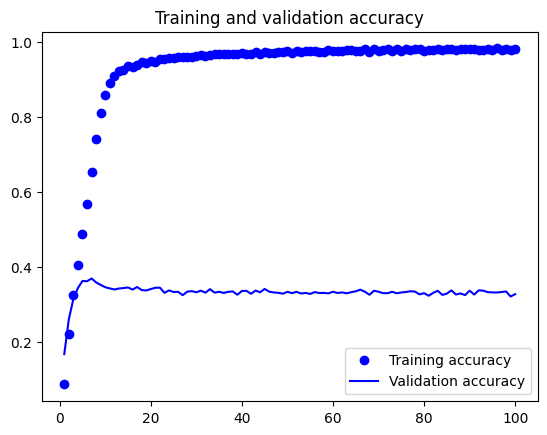

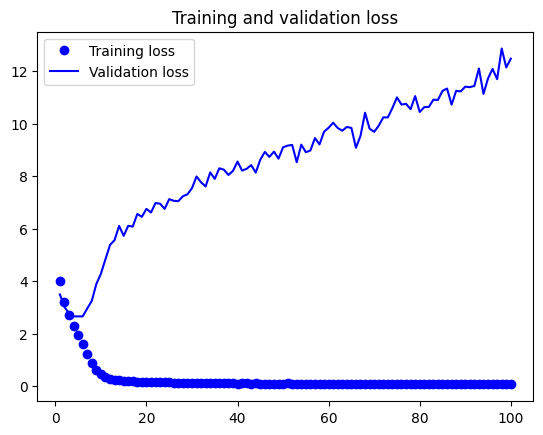

In [ ]:
training_plot(history)

The training peformance is measured on the training dataset, the data the model learns from. The validation peformance is measured on a separate validation dataset, one that the model never saw during training

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test accuracy", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.3407 - loss: 12.1354
Test accuracy 0.3337000012397766


The training accuracy is higher than the testing accuracy. This is because the model learns from the training accuracy, test accuracy is based on unseen data. The training accuracy is 98% while the testing accuracy is 33%. This may mean that the model is overfitting, meaning that the model is memorizing data instead of learning it.

In [ ]:
def cnn_model_dropout(input_shape=(32, 32, 3)):

  model = Sequential()

  #Conv block 1: 32 filters, Maxpool
  model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=input_shape))
  model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  #Conv block 2: 64 filters, Maxpool
  model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
  model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  #Conv block 3: 128 Filters, maxpoool
  model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
  model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  #Flatten the convolutional features
  model.add(Flatten())
  model.add(Dense(512, activation='relu'))
  model.add(Dropout(0.5))
  model.add(Dense(100, activation='softmax'))

  return model


In [ ]:
from tensorflow.keras.optimizers import Adam

model_dropout = cnn_model_dropout()

model_dropout.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['acc']
)
history_dropout = model_dropout.fit(X_train,
                    y_train_cat,
                    batch_size=32,
                    epochs=100,
                    verbose=1,
                    validation_split=.2,
                    )

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - acc: 0.0261 - loss: 4.4155 - val_acc: 0.1128 - val_loss: 3.7920
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.1211 - loss: 3.7283 - val_acc: 0.2074 - val_loss: 3.2698
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.1951 - loss: 3.3170 - val_acc: 0.2525 - val_loss: 3.0270
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - acc: 0.2430 - loss: 3.0560 - val_acc: 0.2984 - val_loss: 2.7939
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.2905 - loss: 2.8353 - val_acc: 0.3219 - val_loss: 2.6798
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - acc: 0.3230 - loss: 2.6810 - val_acc: 0.3397 - val_loss: 2.5855
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.3424 - loss: 2.5570 - val_acc: 0.3641 - val_loss: 2.5002
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - acc: 0.3707 - loss: 2.4096 - val_acc: 0.3721 - val_loss: 2.4250
Epoch 9/100
1250/1250 ━━━━━━━━━

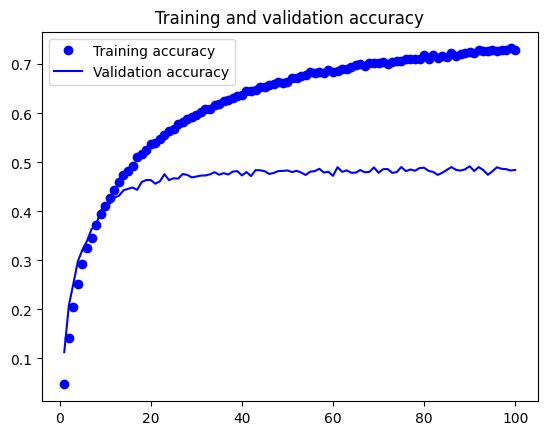

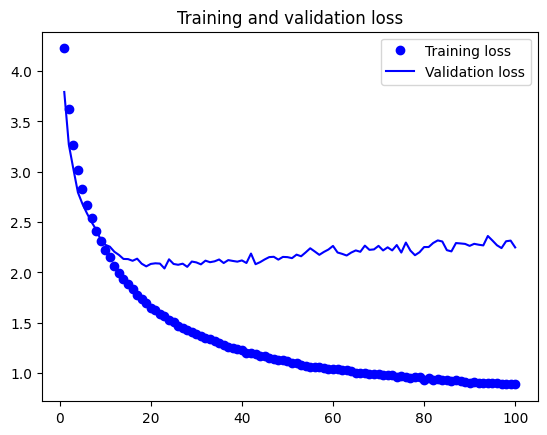

In [ ]:
training_plot(history_dropout)

In [ ]:
test_loss_dropout, test_acc_dropout = model_dropout.evaluate(X_test, y_test_cat)
print("Test accuracy", test_acc_dropout)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.4979 - loss: 2.1774
Test accuracy 0.49559998512268066


Dropout is added after layers that learn features. They are put after the convolutional blocks and after fully connected(Dense) layers. Dropout randomly disables some of the neurons during training, which reduces overfitting, and overall improves validation and test accuracy.

If i had the choice do deploy the model with or without dropout for real world data, i would choose to deploy the one with dropout. This is because the real world images are often unseen and noisy. Dropout also improves generalization making it more applicable for real world applications. It also reduces the risk of overfitting